# 1. Carga de datos

In [8]:
from pathlib import Path

# __file__ no funciona en notebooks, así que usamos Path.cwd()
# Subimos dos niveles: notebooks/ -> src/ -> repo/
repo_root = Path.cwd().parent.parent

dataset_path = repo_root / "data" / "chemical_process_timeseries.csv"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [5]:
df = pd.read_csv(filepath_or_buffer=dataset_path,sep=",")

In [6]:
print(df.shape)
print(df.dtypes)
print(df.head())

(777600, 21)
timestamp                   str
operating_regime            str
reactor_id                  str
ambient_temp_effect     float64
reactor_temp            float64
reactor_pressure        float64
feed_flow_rate          float64
coolant_flow_rate       float64
agitator_speed_rpm      float64
reaction_rate           float64
conversion_rate         float64
selectivity             float64
yield_pct               float64
vibration_rms           float64
motor_current           float64
power_consumption_kw    float64
temp_setpoint           float64
pressure_setpoint       float64
fault_type                int64
efficiency_loss_pct     float64
time_to_fault_min       float64
dtype: object
             timestamp operating_regime reactor_id  ambient_temp_effect  \
0  2024-01-01 00:00:00                A       A_R1             0.000000   
1  2024-01-01 00:01:00                A       A_R1             0.000485   
2  2024-01-01 00:02:00                A       A_R1             0.000970   
3

In [9]:
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values("timestamp").reset_index(drop=True)

print(f"Rango temporal: {df['timestamp'].min()} → {df['timestamp'].max()}")
print(f"Duración total: {df['timestamp'].max() - df['timestamp'].min()}")
print(f"Frecuencia de muestreo estimada: {df['timestamp'].diff().mode()[0]}")

Rango temporal: 2024-01-01 00:00:00 → 2024-03-30 23:59:00
Duración total: 89 days 23:59:00
Frecuencia de muestreo estimada: 0 days 00:00:00


# 2. EDA

## 2.1 Identificación de valores nulos

In [10]:
nulls = df.isnull().sum()
nulls_pct = (nulls / len(df) * 100).round(2)

null_df = pd.DataFrame({"nulos": nulls, "porcentaje": nulls_pct})
null_df = null_df[null_df["nulos"] > 0].sort_values("porcentaje", ascending=False)
print(null_df)

                       nulos  porcentaje
time_to_fault_min     751313       96.62
selectivity            47209        6.07
reactor_pressure       47143        6.06
reactor_temp           46965        6.04
efficiency_loss_pct    46919        6.03
reaction_rate          46830        6.02
pressure_setpoint      46818        6.02
agitator_speed_rpm     46775        6.02
feed_flow_rate         46760        6.01
coolant_flow_rate      46645        6.00
ambient_temp_effect    46561        5.99
motor_current          46617        5.99
yield_pct              46524        5.98
temp_setpoint          46522        5.98
power_consumption_kw   46494        5.98
conversion_rate        46416        5.97
vibration_rms          46459        5.97


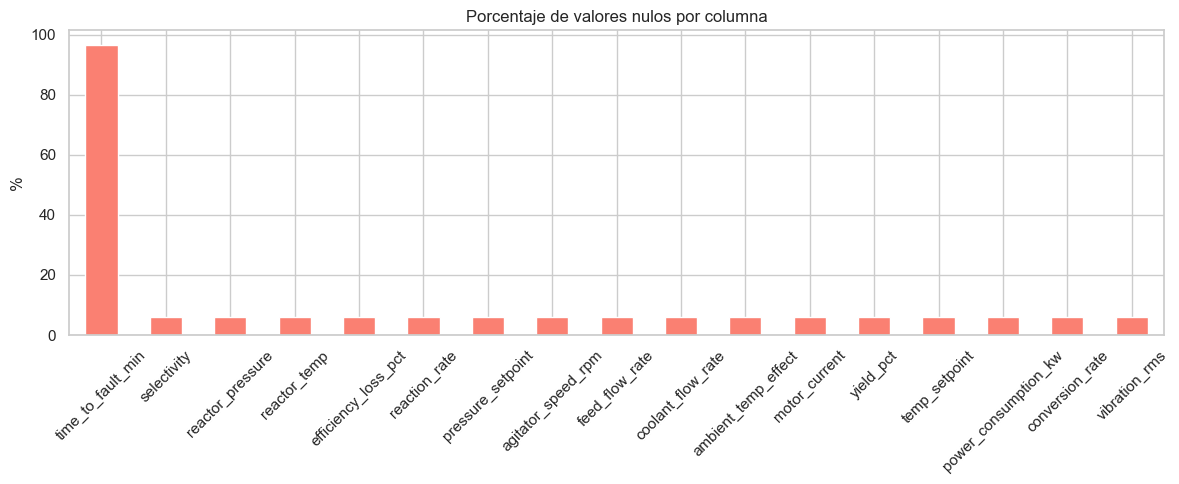

In [11]:
null_df["porcentaje"].plot(kind="bar", color="salmon")
plt.title("Porcentaje de valores nulos por columna")
plt.ylabel("%")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [17]:
# Verificar si los nulos están en las mismas filas
sensor_cols = [col for col in df.columns if col not in 
               ["timestamp", "operating_regime", "reactor_id", "fault_type", "time_to_fault_min"]]

null_rows = df[sensor_cols].isnull().any(axis=1)
print(f"Filas con al menos un nulo en sensores: {null_rows.sum()}")
print(f"Filas con TODOS los sensores a NaN: {df[sensor_cols].isnull().all(axis=1).sum()}")

Filas con al menos un nulo en sensores: 489136
Filas con TODOS los sensores a NaN: 0


Los nulos están dispersos en filas distintas, no son caídas totales del sistema. Esto significa que hay fallos puntuales de sensores individuales, y eliminar filas no es viable porque perderíamos demasiada información (~63% de las filas tiene algún nulo).
La estrategia correcta aquí es imputación, y dado que es una serie temporal con diferentes reactores y regímenes, aplicaremos interpolación temporal por grupos.

## 2.2 Imputación de valores nulos

In [18]:
# Ordenar por reactor y tiempo antes de interpolar
df = df.sort_values(["reactor_id", "operating_regime", "timestamp"]).reset_index(drop=True)

In [19]:
# Interpolación temporal dentro de cada grupo reactor + régimen
df[sensor_cols] = df.groupby(["reactor_id", "operating_regime"])[sensor_cols] \
                    .transform(lambda x: x.interpolate(method="linear", limit=10))

In [20]:

for col in sensor_cols:
    df[col] = df.groupby(["reactor_id", "operating_regime"])[col] \
                .transform(lambda x: x.fillna(x.median()))

remaining = df[sensor_cols].isnull().sum().sum()
print(f"Nulos restantes en sensores: {remaining}")
print(df.isnull().sum())

Nulos restantes en sensores: 0
timestamp                    0
operating_regime             0
reactor_id                   0
ambient_temp_effect          0
reactor_temp                 0
reactor_pressure             0
feed_flow_rate               0
coolant_flow_rate            0
agitator_speed_rpm           0
reaction_rate                0
conversion_rate              0
selectivity                  0
yield_pct                    0
vibration_rms                0
motor_current                0
power_consumption_kw         0
temp_setpoint                0
pressure_setpoint            0
fault_type                   0
efficiency_loss_pct          0
time_to_fault_min       751313
dtype: int64


In [22]:
df["time_to_fault_min"] = df["time_to_fault_min"].fillna(-1)

# Verificación
print(df["time_to_fault_min"].isnull().sum())  # Debe dar 0
print(df["time_to_fault_min"].value_counts().head())

0
time_to_fault_min
-1.0      751313
 187.0        35
 180.0        35
 178.0        35
 169.0        35
Name: count, dtype: int64


In [23]:
print(f"Total filas: {len(df)}")
print(f"Filas sin fallo (time_to_fault = -1): {(df['time_to_fault_min'] == -1).sum()}")
print(f"Filas con fallo registrado: {(df['time_to_fault_min'] != -1).sum()}")
print(f"Nulos totales en el dataset: {df.isnull().sum().sum()}")

Total filas: 777600
Filas sin fallo (time_to_fault = -1): 751313
Filas con fallo registrado: 26287
Nulos totales en el dataset: 0


## 2.3 Outliers

Los boxplots pueden ser útiles para identificar valores extremos.

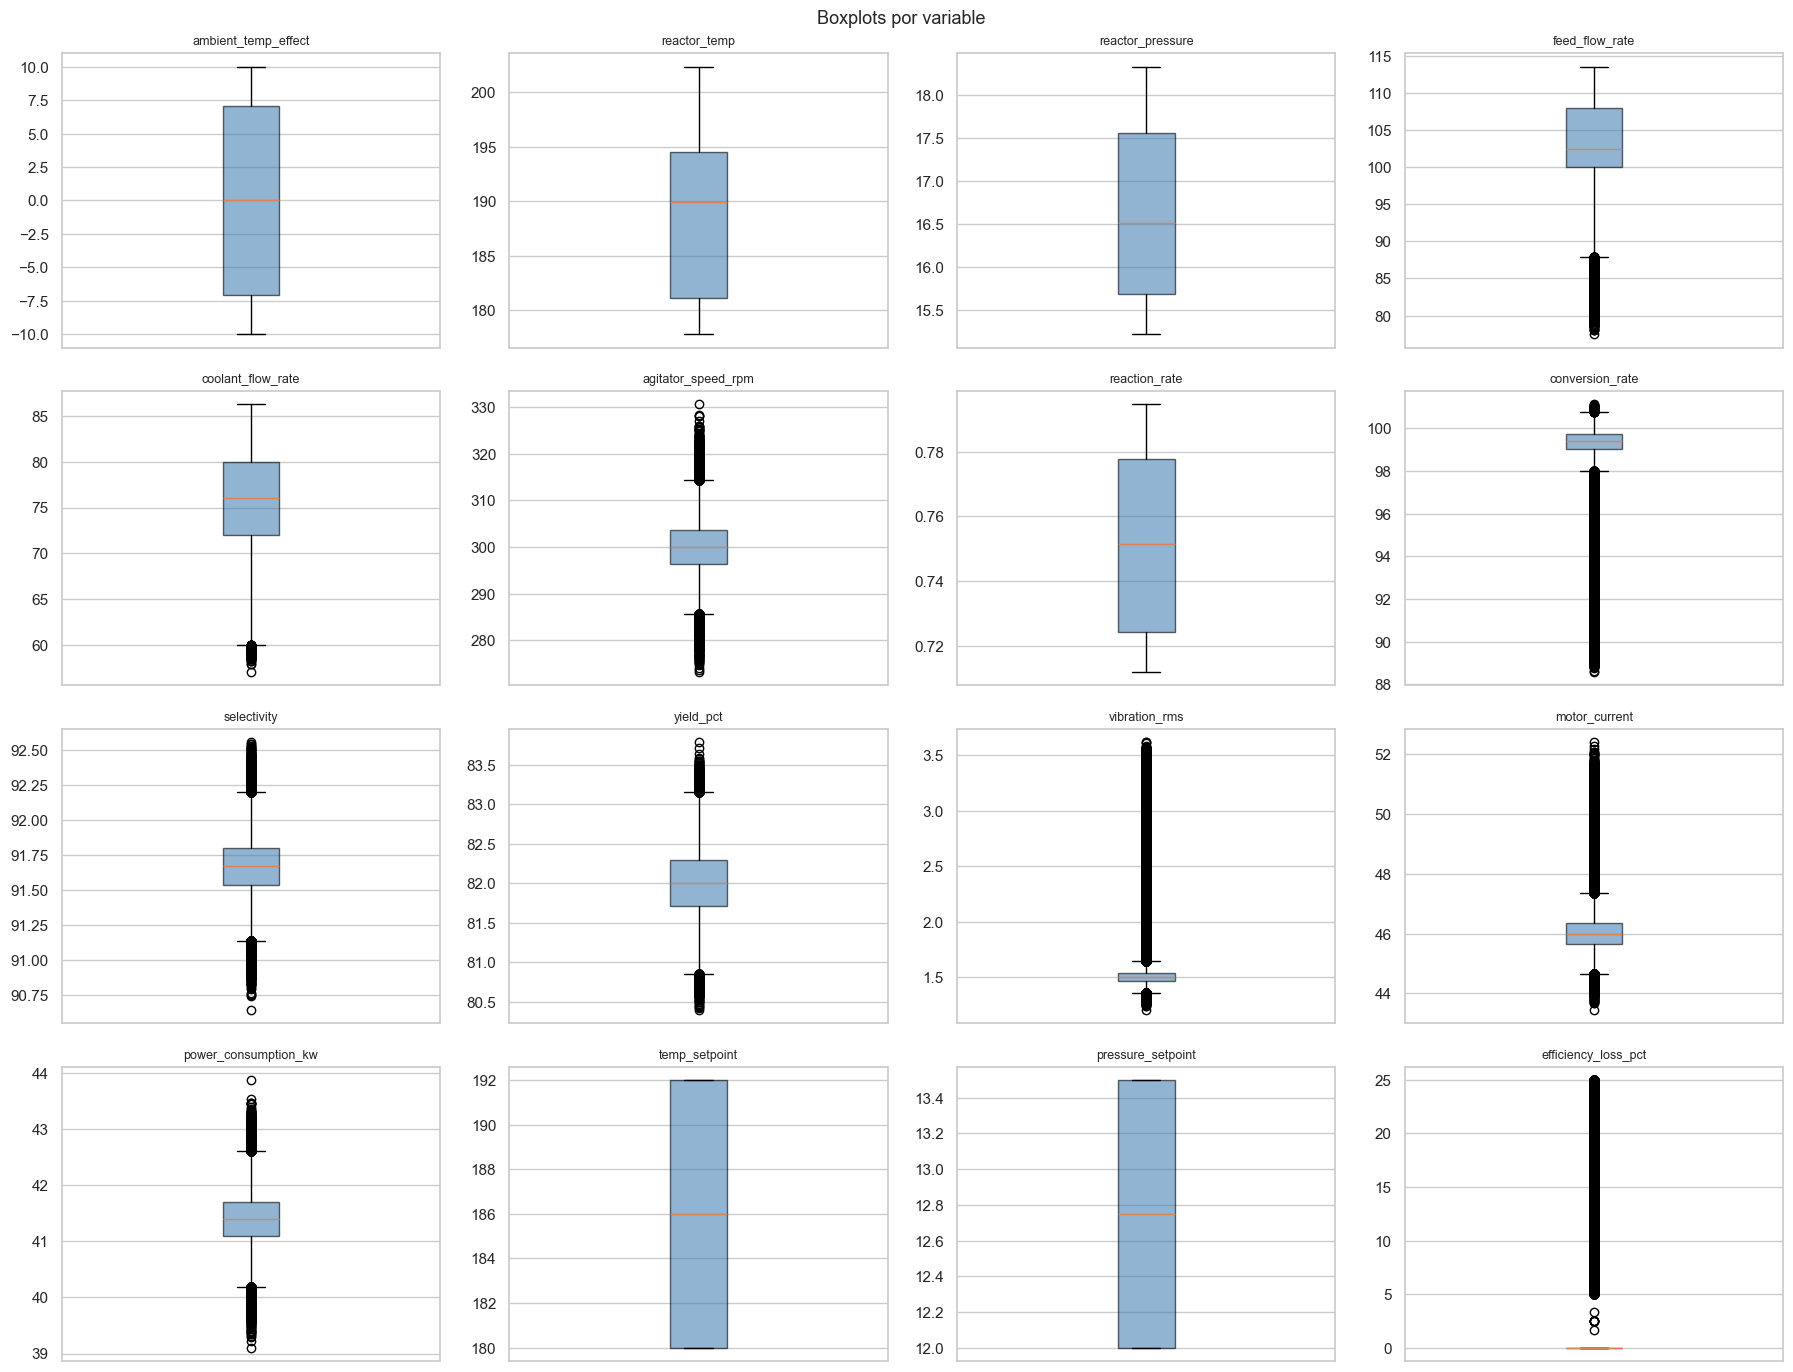

In [24]:
fig, axes = plt.subplots(4, 4, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(sensor_cols):
    axes[i].boxplot(df[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor="steelblue", alpha=0.6))
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xticks([])

# Ocultar subplots sobrantes
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Boxplots por variable", fontsize=13)
plt.tight_layout()
plt.show()

In [25]:
def detect_outliers_iqr(df, cols):
    results = []
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
        results.append({
            "columna": col,
            "lower_bound": round(lower, 3),
            "upper_bound": round(upper, 3),
            "n_outliers": n_outliers,
            "pct_outliers": round(n_outliers / len(df) * 100, 2)
        })
    return pd.DataFrame(results).sort_values("pct_outliers", ascending=False)

outlier_df = detect_outliers_iqr(df, sensor_cols)
print(outlier_df)

                 columna  lower_bound  upper_bound  n_outliers  pct_outliers
15   efficiency_loss_pct        0.000        0.000       27908          3.59
10         vibration_rms        1.355        1.646       13919          1.79
11         motor_current       44.643       47.372       10976          1.41
5     agitator_speed_rpm      285.561      314.428        7253          0.93
7        conversion_rate       98.008      100.773        6105          0.79
8            selectivity       91.136       92.199        5962          0.77
12  power_consumption_kw       40.185       42.617        5994          0.77
3         feed_flow_rate       87.950      120.019        1593          0.20
9              yield_pct       80.855       83.150        1450          0.19
4      coolant_flow_rate       60.008       91.938         108          0.01
1           reactor_temp      161.049      214.547           0          0.00
2       reactor_pressure       12.863       20.373           0          0.00

In [26]:
# Si los outliers se concentran en fault_type != 0, son información valiosa, no ruido
for col in outlier_df[outlier_df["pct_outliers"] > 1]["columna"]:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    mask = (df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)
    
    fault_dist = df.loc[mask, "fault_type"].value_counts(normalize=True).round(3)
    print(f"\n{col} — distribución de fault_type en outliers:")
    print(fault_dist)


efficiency_loss_pct — distribución de fault_type en outliers:
fault_type
1    0.328
4    0.267
2    0.245
3    0.160
0    0.000
Name: proportion, dtype: float64

vibration_rms — distribución de fault_type en outliers:
fault_type
4    0.495
0    0.489
1    0.007
2    0.005
3    0.005
Name: proportion, dtype: float64

motor_current — distribución de fault_type en outliers:
fault_type
4    0.494
0    0.491
1    0.006
2    0.005
3    0.004
Name: proportion, dtype: float64


In [27]:

for col in ["vibration_rms", "motor_current"]:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    mask = (df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)
    
    print(f"\n{col} — outliers en fault_type=0 por reactor:")
    print(df.loc[mask & (df["fault_type"] == 0), "reactor_id"].value_counts())
    print(f"\n{col} — outliers en fault_type=0 por operating_regime:")
    print(df.loc[mask & (df["fault_type"] == 0), "operating_regime"].value_counts())


vibration_rms — outliers en fault_type=0 por reactor:
reactor_id
B_R2    1879
B_R3    1829
B_R1    1799
A_R1     450
A_R3     436
A_R2     411
Name: count, dtype: int64

vibration_rms — outliers en fault_type=0 por operating_regime:
operating_regime
B    5507
A    1297
Name: count, dtype: int64

motor_current — outliers en fault_type=0 por reactor:
reactor_id
B_R2    951
B_R1    936
B_R3    905
A_R3    878
A_R1    868
A_R2    855
Name: count, dtype: int64

motor_current — outliers en fault_type=0 por operating_regime:
operating_regime
B    2792
A    2601
Name: count, dtype: int64


Los outliers están distribuidos por todos los reactores y ambos regímenes, no hay concentración en ninguno en particular. Eso descarta que sean errores de un sensor específico o un reactor defectuoso.
La conclusión general es que en este dataset no hay outliers que deban tratarse. Los valores extremos tienen explicación física o están directamente relacionados con los fallos. Eliminarlos empeoraría el modelo.

## 2.4 Distribución de variables

In [12]:
for col in ["operating_regime", "reactor_id"]:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())


--- operating_regime ---
operating_regime
A    388800
B    388800
Name: count, dtype: int64

--- reactor_id ---
reactor_id
A_R1    129600
A_R2    129600
A_R3    129600
B_R1    129600
B_R2    129600
B_R3    129600
Name: count, dtype: int64


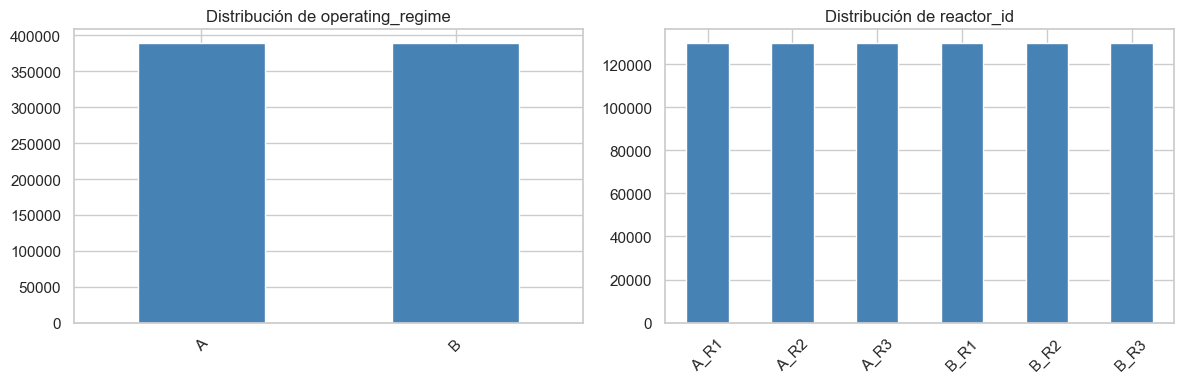

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col in zip(axes, ["operating_regime", "reactor_id"]):
    df[col].value_counts().plot(kind="bar", ax=ax, color="steelblue")
    ax.set_title(f"Distribución de {col}")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

                         count     mean      std      min      25%      50%  \
ambient_temp_effect   731039.0   -0.002    7.071  -10.000   -7.075   -0.002   
reactor_temp          730635.0  187.967    6.765  177.794  181.115  191.454   
reactor_pressure      730457.0   16.621    0.959   15.214   15.680   16.027   
feed_flow_rate        730840.0  103.915    4.299   77.477   99.975  102.536   
coolant_flow_rate     730955.0   75.941    4.436   57.025   71.981   76.000   
agitator_speed_rpm    730825.0  299.995    5.523  273.136  296.309  299.983   
reaction_rate         730770.0    0.752    0.027    0.712    0.724    0.767   
conversion_rate       731184.0   99.352    0.704   88.575   99.044   99.390   
selectivity           730391.0   91.668    0.201   90.645   91.532   91.668   
yield_pct             731076.0   82.003    0.403   80.399   81.714   82.002   
vibration_rms         731141.0    1.509    0.125    1.204    1.464    1.501   
motor_current         730983.0   46.024    0.584   4

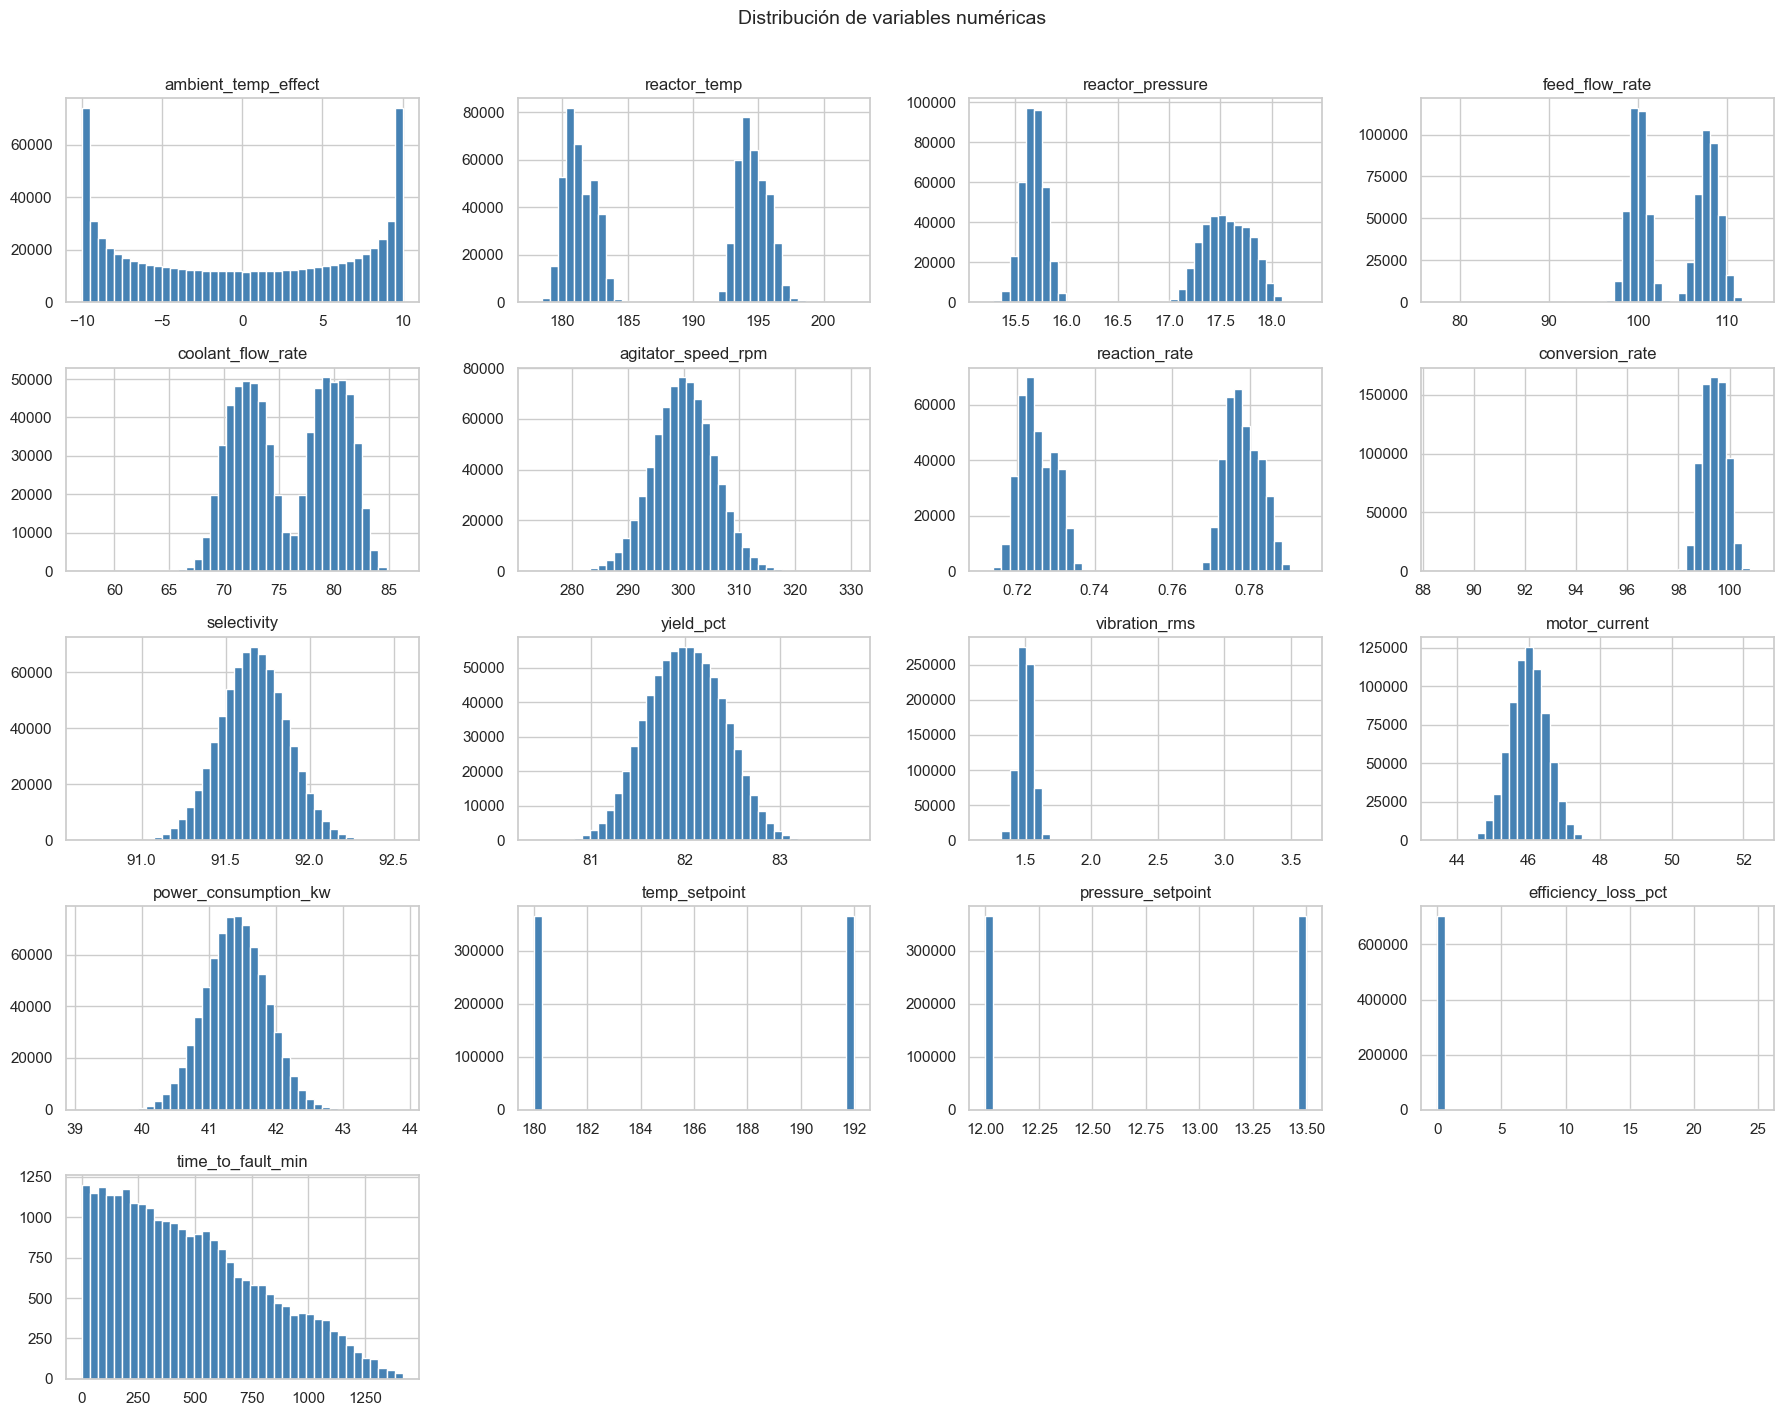

In [14]:
num_cols = df.select_dtypes(include="float64").columns.tolist()
print(df[num_cols].describe().T.round(3))
df[num_cols].hist(bins=40, figsize=(18, 14), color="steelblue", edgecolor="white")
plt.suptitle("Distribución de variables numéricas", y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

In [15]:
print(df["fault_type"].value_counts())
print(f"\nClases: {sorted(df['fault_type'].unique())}")

fault_type
0    749699
1      9143
4      7442
2      6842
3      4474
Name: count, dtype: int64

Clases: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


### Variable objetivo fault_type

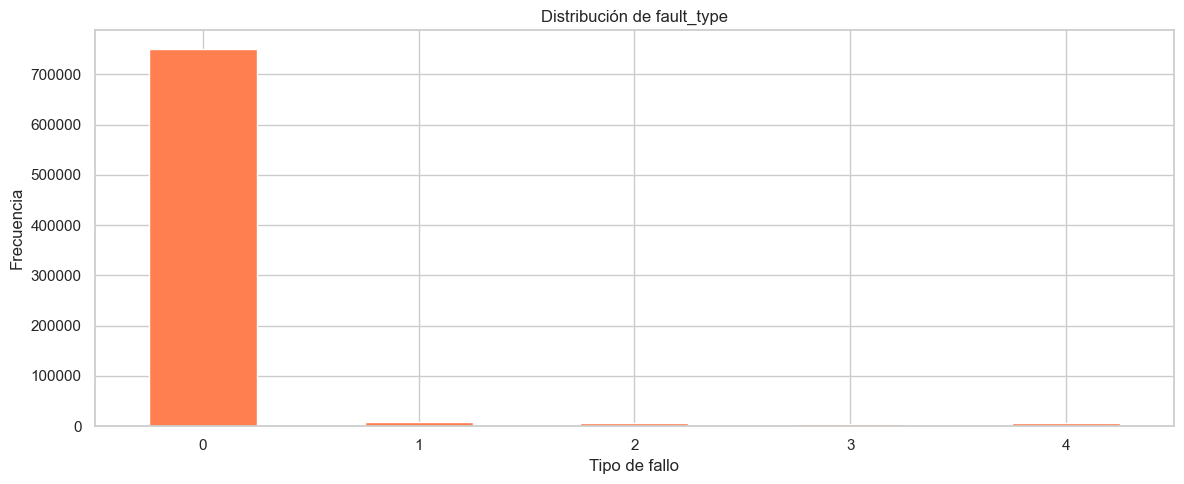

In [16]:
df["fault_type"].value_counts().sort_index().plot(kind="bar", color="coral")
plt.title("Distribución de fault_type")
plt.xlabel("Tipo de fallo")
plt.ylabel("Frecuencia")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()